In [2]:
%pip install fasttext-wheel

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pybind11-3.0.2-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.2-py3-none-any.whl (310 kB)
Failed to build fasttext-wheel
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for fasttext-wheel (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [48 lines of output]
      C:\Users\mayank goyal\AppData\Local\Temp\pip-build-env-jd72p5jt\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please use the underscore name 'description_file' instead.
              (Affected: fasttext-wheel).
      
              Available configuration options are listed in:
              https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
      
              This deprecation is overdue, please update your proje

In [4]:
%pip install gensim pandas scikit-learn

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.4 MB 15.8 MB/s eta 0:00:02
   ----------- ---------------------------- 7.1/24.4 MB 27.8 MB/s eta 0:00:01
   ------------------------ --------------- 14.9/24.4 MB 31.2 MB/s eta 0:00:01
   --------------------------------- ------ 20.4/24.4 MB 31.3 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 31.2 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 27.3 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from utils import clean_text, get_sentence_vector

In [6]:
df = pd.read_csv('farmers_dataset.csv')
df['text'] = df['text'].apply(clean_text)

In [7]:
df.head()

,text,intent
0,what boi for ganna,advice
1,how is the mosam td,weather
2,need bank for farming,subsidy
3,govt scheme for tomato,subsidy
4,kya kal temp hogi,weather


In [8]:
sentences = [text.split() for text in df['text']]

In [9]:
df.shape

(15000, 2)

In [10]:
#vector_size=100: Length of the word vector
# window=5: Context window
# min_count=1: Don't ignore rare words (crucial for farmers' slang!)
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, epochs=10)

In [13]:
sim = model.wv.similarity('wheat', 'wheet')
print(f"💡 Similarity between 'wheat' and typo 'wheet': {sim:.2f}")

In [14]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [15]:
# get_sentence_vector is imported from utils.py

In [16]:
X = np.array([get_sentence_vector(text, model) for text in df['text']])
y = df['intent']

# 3. Split data for testing (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Initialize and train
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Check accuracy
y_pred = clf.predict(X_test)
print(f"✅ Classifier Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

✅ Classifier Accuracy: 100.00%


In [18]:
def route_sms(user_query):
    # Clean and vectorize
    clean_query = user_query.lower()
    vector = get_sentence_vector(clean_query, model).reshape(1, -1)
    
    # Predict
    prediction = clf.predict(vector)[0]
    confidence = np.max(clf.predict_proba(vector)) # How sure is the model?
    
    return prediction, confidence

# Test it out!
test_query = "aj wheat ka rate kya hai" # Mixing Hindi/English slang
intent, conf = route_sms(test_query)

print(f"📱 Query: {test_query}")
print(f"🤖 Detected Intent: {intent.upper()} ({conf*100:.1f}% confidence)")

📱 Query: aj wheat ka rate kya hai
🤖 Detected Intent: MARKET (100.0% confidence)


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

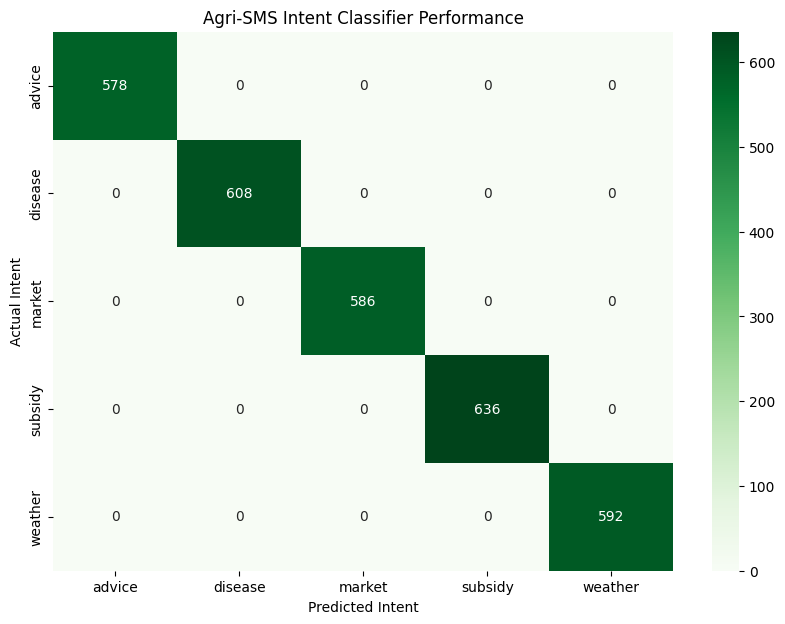

In [20]:
y_pred = clf.predict(X_test)

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = sorted(df['intent'].unique())

# 3. Plotting the "Fabulous" Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Intent')
plt.ylabel('Actual Intent')
plt.title('Agri-SMS Intent Classifier Performance')
plt.show()

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      advice       1.00      1.00      1.00       578
     disease       1.00      1.00      1.00       608
      market       1.00      1.00      1.00       586
     subsidy       1.00      1.00      1.00       636
     weather       1.00      1.00      1.00       592

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [23]:
import pickle

# 1. Save the Logistic Regression Classifier
with open('intent_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

# 2. Save the Word2Vec Model (Gensim format)
model.save("agri_word2vec.model")

print("✅ Files Saved: 'intent_classifier.pkl' and 'agri_word2vec.model'")